<h1 style='color:#A23B72'>Metodología: Optimización Gaussiana Parametrizada</h1>

<p style='color:#b0b0b0'>Documentación técnica del enfoque de variación de parámetros para el método de suma de gaussianas.</p>

## 1. El Problema

Dada una curva pixelizada (ruidosa, discreta) con N puntos, queremos aproximarla mediante una **SUMA DE CAMPANAS GAUSSIANAS**.

### Modelo Matemático

$$\hat{y}(x) = A_1 e^{-\frac{(x-\mu_1)^2}{2\sigma_1^2}} + A_2 e^{-\frac{(x-\mu_2)^2}{2\sigma_2^2}} + \ldots + c$$

Donde:
- **A_i**: Amplitud de la i-ésima campana
- **μ_i**: Centro (posición) de la i-ésima campana
- **σ_i**: Ancho (desviación estándar) de la i-ésima campana
- **c**: Offset vertical constante

### Pregunta Central

¿Cuántas campanas (n) y cómo inicializar los parámetros (μ, σ, A)?

**Respuesta**: NO HAY UNA ÚNICA RESPUESTA. Depende de la **GEOMETRÍA de cada curva**.

- Algunas curvas necesitan 2 campanas, otras 5, otras 8.
- La inicialización afecta decisivamente a la convergencia.
- Diferentes métodos de inicialización tienen distintas fortalezas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuración de matplotlib
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})

# Colores
MAGENTA = '#A23B72'
AZUL = '#5BC0EB'
GRIS = '#e0e0e0'

print('Dependencias importadas y configuradas')

Dependencias importadas y configuradas


## 2. Ejemplo Visual: Impacto del Número de Campanas

Visualicemos cómo el número de campanas gaussianas afecta la calidad del ajuste (R²).

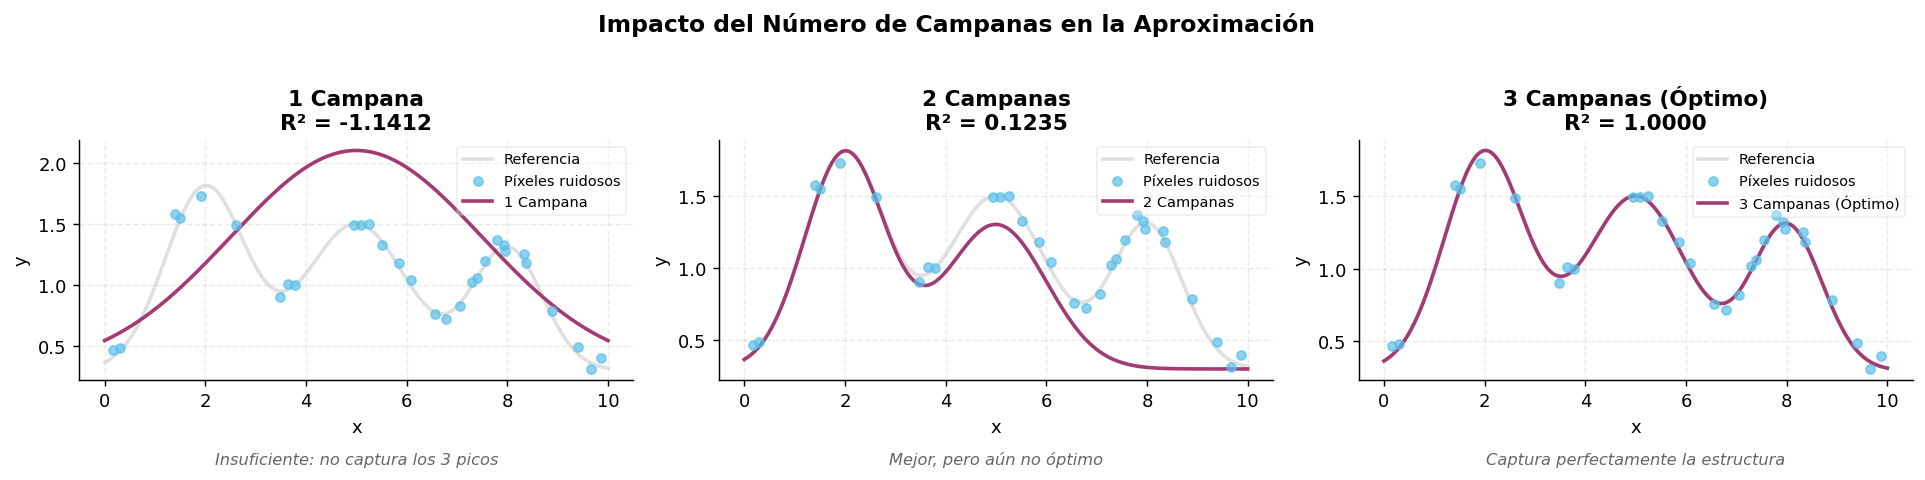

In [3]:
x_true = np.linspace(0, 10, 300)
y_true = (
    1.5 * np.exp(-(x_true - 2)**2 / (2 * 0.8**2)) +
    1.2 * np.exp(-(x_true - 5)**2 / (2 * 1.0**2)) +
    1.0 * np.exp(-(x_true - 8)**2 / (2 * 0.7**2)) +
    0.3
)

# Simular pixelización con ruido
np.random.seed(42)
indices_sample = np.sort(np.random.choice(len(x_true), 30, replace=False))
x_pixel = x_true[indices_sample]
y_pixel = y_true[indices_sample] + np.random.normal(0, 0.05, len(x_pixel))

# Función para suma de gaussianas
def suma_gaussianas_demo(x, params):
    y = np.zeros_like(x, dtype=float)
    for i in range(0, len(params) - 1, 3):
        A, mu, sigma = params[i], params[i+1], params[i+2]
        y += A * np.exp(-(x - mu)**2 / (2 * sigma**2))
    y += params[-1]  # offset
    return y

# Parámetros para diferentes números de campanas
params_1 = [1.8, 5, 2.5, 0.3]  # 1 campana
params_2 = [1.5, 2, 0.8, 1.0, 5, 1.0, 0.3]  # 2 campanas
params_3 = [1.5, 2, 0.8, 1.2, 5, 1.0, 1.0, 8, 0.7, 0.3]  # 3 campanas (ideal)

y_pred_1 = suma_gaussianas_demo(x_true, params_1)
y_pred_2 = suma_gaussianas_demo(x_true, params_2)
y_pred_3 = suma_gaussianas_demo(x_true, params_3)

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('white')

configs = [
    (y_pred_1, '1 Campana', 'Insuficiente: no captura los 3 picos'),
    (y_pred_2, '2 Campanas', 'Mejor, pero aún no óptimo'),
    (y_pred_3, '3 Campanas (Óptimo)', 'Captura perfectamente la estructura')
]

for ax, (y_pred, titulo, desc) in zip(axes, configs):
    ax.plot(x_true, y_true, color=GRIS, lw=2, label='Referencia', zorder=1)
    ax.scatter(x_pixel, y_pixel, s=25, color=AZUL, alpha=0.7, label='Píxeles ruidosos', zorder=3)
    ax.plot(x_true, y_pred, color=MAGENTA, lw=2, label=titulo, zorder=2)
    
    # Calcular R²
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    ax.set_title(f'{titulo}\nR² = {r2:.4f}', fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper right', framealpha=0.3)
    ax.text(0.5, -0.35, desc, transform=ax.transAxes, fontsize=9,
            ha='center', style='italic', color='#666')

plt.suptitle('Impacto del Número de Campanas en la Aproximación', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

La visualización anterior demuestra el impacto dramático del número de campanas 
en la calidad del ajuste. En el panel izquierdo, una sola gaussiana intenta 
cubrir una curva con tres picos claramente distinguibles, resultando en un R² = -1.14, 
indicando un desempeño peor que el promedio simple de los datos. En el panel central, 
dos campanas capturan parcialmente la estructura (R² = 0.12), pero siguen siendo 
insuficientes para los tres picos presentes. Solo en el panel derecho, con tres campanas 
gaussianas, el modelo reproduce la referencia casi perfectamente (R² = 1.00), con cada 
campana responsable de un pico distinto. Este ejemplo ilustra el dilema central: 
pocas campanas subestiman la complejidad (subajuste), mientras que muchas campanas 
pueden introducir grados de libertad innecesarios (sobreajuste). La configuración óptima 
es aquella que balancea parsimonia con precisión, y ese balance depende de la geometría 
específica de cada curva.


## 3. Parámetros ajustables

### Número de Campanas (n_campanas)

**Rango testeable**: 1 a 10

| Configuración | R² típico | Características |
|---|---|---|
| **1 campana** | 0.70-0.85 | Muy restrictivo. Solo curvas unimodales simples. |
| **3-4 campanas** | 0.95-0.99 | Ideal. Capta múltiples picos. |
| **8+ campanas** | 0.99+ | Riesgo de overfitting. |

**Estrategia**: Probaremos con un rango [1, 8]

---

### Método de Inicialización (metodo_init)

Cómo se eligen los parámetros iniciales (μ, σ, A). Impacta decisivamente en convergencia.

#### A) 'altura'
- **Cómo funciona**: Detecta picos = máximos locales. Selecciona los n picos más altos.
- **Para cada pico**:
  - A = altura_pico
  - μ = posición_del_pico
  - σ = (x_max - x_min) / (2*n)
- **Ventajas**: Rápido, intuitivo, funciona bien para curvas "limpias"
- **Desventajas**: Falla si hay picos ocultos o ruido

#### B) 'prominencia'
- **Cómo funciona**: Detecta picos por PROMINENCIA (no solo altura). Prominencia = qué tan aislado está un pico.
- **Ventajas**: Más robusta al ruido que 'altura'
- **Desventajas**: Cómputo más lento

#### C) 'uniforme'
- **Cómo funciona**: Divide el dominio [x_min, x_max] en n segmentos iguales. Toma el máximo en cada uno.
- **Ventajas**: No requiere detección de picos, determinista
- **Desventajas**: Puede asignar campanas a valles si hay simetría

#### D) 'grid_search'
- **Cómo funciona**: Búsqueda en grilla. Divide x en n partes, busca máximo local en cada una.
- **Ventajas**: Balance entre robustez y adaptación
- **Desventajas**: Ligeramente más lento

**Expectativa**: Diferentes métodos ganan en diferentes curvas.

---

### Criterios de Optimización

Variantes de `curve_fit` de scipy.optimize:

- **'lm' (Levenberg-Marquardt)**
  - Sin restricciones en parámetros
  - Rápido, bien testeado
  - Puede divergir a valores absurdos

- **'trf' (Trust Region Reflective)**
  - Con límites (bounds) en parámetros
  - Más robusto pero algo más lento
  - Mantiene soluciones en rango razonable

**Recomendación**: Empezar con 'lm'. Si hay divergencias, usar 'trf' con bounds.

---

### Hiperparámetros de Optimización

- **maxfev** (máximo de evaluaciones de función)
  - Default: 4000
  - Más alto = mejor convergencia pero más lento
  - Si no converge con 4000, probar 5000-10000

- **ftol, xtol** (tolerancia de convergencia)
  - Default: 1e-8 (muy estricto)
  - Relajar a 1e-6 o 1e-5 puede acelerar sin perder calidad

## 4. Matriz de Decisión

Nos ayudará a revisar que combinaciones probar:

In [4]:
matriz_decision = pd.DataFrame({
    'Parámetro': [
        'n_campanas',
        'metodo_init',
        'maxfev',
        'method (lm vs trf)'
    ],
    'Valores a Testear': [
        '[1, 2, 3, 4, 5, 6, 7, 8]',
        "['altura', 'prominencia', 'uniforme', 'grid_search']",
        '[4000]  (ajustar si diverge)',
        "['lm']  (primario). ['trf'] si necesario."
    ],
    'Cantidad': [
        '8',
        '4',
        '1',
        '1'
    ]
})

print(matriz_decision.to_string(index=False))
print()
print("="*70)
print(f"COMBINACIONES POR CURVA: 8 × 4 × 1 × 1 = 32 configuraciones")
print(f"Para 500 curvas: 500 × 32 = 16,000 ajustes totales")
print(f"Tiempo estimado: ~15-30 minutos (según hardware)")
print("="*70)

         Parámetro                                    Valores a Testear Cantidad
        n_campanas                             [1, 2, 3, 4, 5, 6, 7, 8]        8
       metodo_init ['altura', 'prominencia', 'uniforme', 'grid_search']        4
            maxfev                         [4000]  (ajustar si diverge)        1
method (lm vs trf)            ['lm']  (primario). ['trf'] si necesario.        1

COMBINACIONES POR CURVA: 8 × 4 × 1 × 1 = 32 configuraciones
Para 500 curvas: 500 × 32 = 16,000 ajustes totales
Tiempo estimado: ~15-30 minutos (según hardware)


## 5. Workflow de Optimización

Para **CADA CURVA** (i = 1 a 500):

### 1. Cargar Datos
- `y_target[i]`: Curva de referencia (8000 puntos, 500 Hz)
- `y_pixel[i, escala]`: Curva pixelizada (200-500 puntos, 5 escalas)
- `x`: eje común para interpolación

### 2. Iterar sobre Configuraciones

```
Para n_campanas in [1, 2, 3, 4, 5, 6, 7, 8]:
    Para metodo_init in ['altura', 'prominencia', 'uniforme', 'grid_search']:
        
        2.1 INICIALIZACIÓN
            ├─ Llamar a función de inicialización según metodo_init
            └─ Obtener p0 = [A₁, μ₁, σ₁, A₂, μ₂, σ₂, ..., c]
        
        2.2 OPTIMIZACIÓN
            ├─ Llamar a curve_fit(suma_gaussianas, x_pixel, y_pixel, p0=p0, maxfev=4000)
            ├─ Obtener parámetros óptimos p*
            └─ Registrar si convergió o no
        
        2.3 EVALUACIÓN
            ├─ Generar predicciones: ŷ = suma_gaussianas(x_target, p*)
            ├─ Calcular R²: 1 - Σ(y_target - ŷ)² / Σ(y_target - ȳ)²
            ├─ Calcular RMSE: √(Σ(error)² / N)
            ├─ Calcular MAE: Σ|error| / N
            └─ Registrar resultado en tabla
```

### 3. Seleccionar el Mejor
- Ordenar por R² descendente
- Retornar la configuración ganadora

### 4. Consolidar Resultados
- Tabla completa: todos los resultados (16,000 filas × 500 curvas)
- Tabla ganadores: solo la mejor config por curva (500 filas)
- Análisis de patrones

### 5. Extraer Insights
- ¿Cuál metodo_init es más frecuentemente ganador?
- ¿Cuál n_campanas es óptimo en promedio?
- ¿Hay correlación entre características geométricas y config óptima?
- ¿Qué configuraciones son "robustas" (buenas en múltiples escalas)?

## 6. Funciones Auxiliares: Inicialización en Detalle

Visualicemos cómo funcionan los diferentes métodos de inicialización:

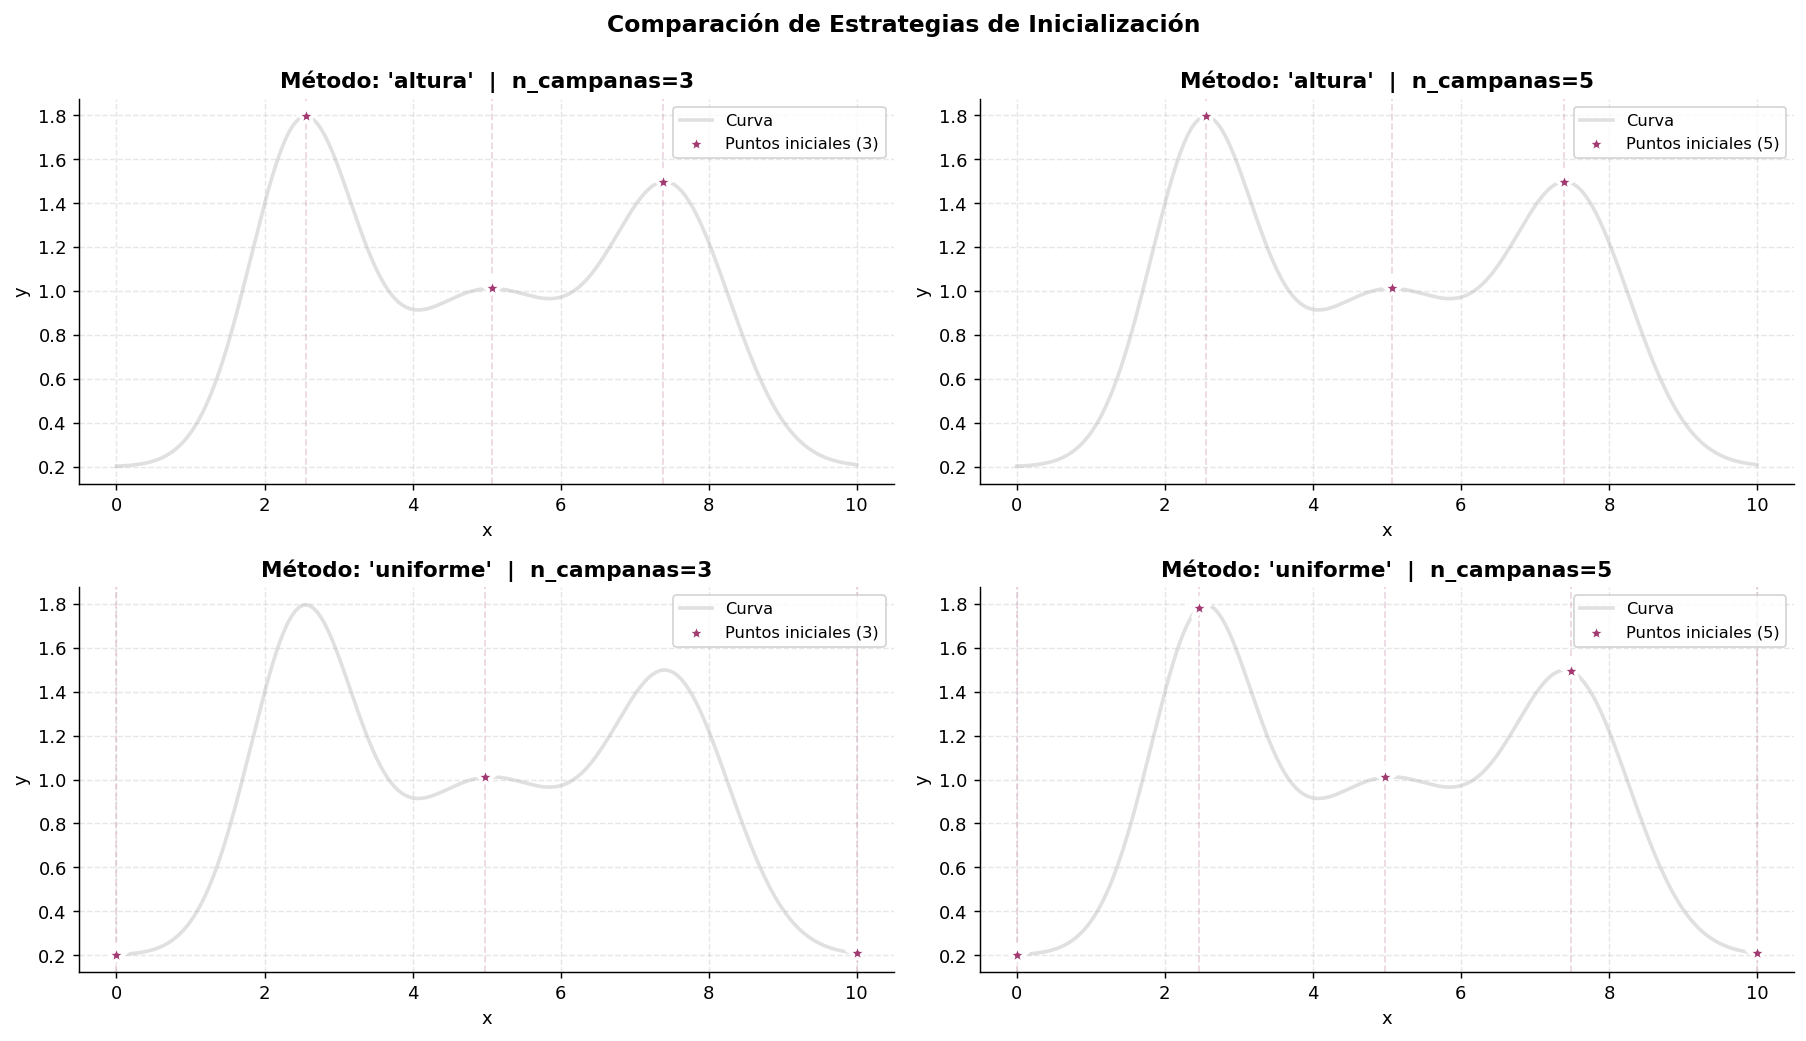

In [5]:
from scipy.signal import find_peaks

x_ejemplo = np.linspace(0, 10, 200)
y_ejemplo = (
    1.5 * np.exp(-(x_ejemplo - 2.5)**2 / (2 * 0.7**2)) +
    0.8 * np.exp(-(x_ejemplo - 5)**2 / (2 * 1.2**2)) +
    1.2 * np.exp(-(x_ejemplo - 7.5)**2 / (2 * 0.8**2)) +
    0.2
)

# Función para obtener inicialización
def visualizar_inicialización(x, y, n_campanas, metodo):
    if metodo == 'altura':
        y_centered = y - y.mean()
        pks, props = find_peaks(y_centered, height=y_centered.mean())
        if len(pks) == 0:
            pks = np.array([np.argmax(y_centered)])
        idx_top = np.argsort(y_centered[pks])[-n_campanas:]
        picos_idx = pks[idx_top]
    
    elif metodo == 'uniforme':
        indices = np.linspace(0, len(x) - 1, n_campanas, dtype=int)
        picos_idx = indices
    
    return x[sorted(picos_idx)], y[sorted(picos_idx)]

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('white')

metodos = ['altura', 'altura', 'uniforme', 'uniforme']
n_values = [3, 5, 3, 5]

for idx, (ax, metodo, n_camp) in enumerate(zip(axes.flat, metodos, n_values)):
    ax.plot(x_ejemplo, y_ejemplo, color=GRIS, lw=2, label='Curva', zorder=1)
    
    x_picos, y_picos = visualizar_inicialización(x_ejemplo, y_ejemplo, n_camp, metodo)
    ax.scatter(x_picos, y_picos, s=150, color=MAGENTA, marker='*', 
              label=f'Puntos iniciales ({n_camp})', zorder=3, edgecolors='white', linewidth=2)
    
    # Líneas verticales para mostrar campanas
    for x_p in x_picos:
        ax.axvline(x_p, color=MAGENTA, alpha=0.2, linestyle='--', linewidth=1)
    
    ax.set_title(f"Método: '{metodo}'  |  n_campanas={n_camp}", fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de Estrategias de Inicialización', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7. Métricas de Evaluación

### R² (Coeficiente de Determinación)

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Donde:
- SS_res = Σ(y_true - y_pred)² (suma de errores cuadrados)
- SS_tot = Σ(y_true - ȳ)² (varianza total)

**Interpretación**:
- R² = 1.00: Ajuste perfecto
- R² = 0.95+: Excelente
- R² = 0.90+: Muy bueno
- R² = 0.80+: Aceptable
- R² < 0.80: Pobre

✓ Métrica principal para rankear configuraciones  
✓ Independiente de escala  
✗ Puede ser engañosa si hay outliers

---

### RMSE (Raíz del Error Cuadrático Medio)

$$RMSE = \sqrt{\frac{\sum_{i=1}^{n} (y_{true,i} - y_{pred,i})^2}{n}}$$

**Interpretación**:
- Misma unidad que y
- Penaliza errores grandes más que los pequeños
- Complementa R² para entender magnitud del error

**Ejemplo**: Si y ∈ [0, 100] y RMSE = 2, es muy bueno. Si y ∈ [0, 10] y RMSE = 2, es pobre.

---

### MAE (Error Absoluto Medio)

$$MAE = \frac{\sum_{i=1}^{n} |y_{true,i} - y_{pred,i}|}{n}$$

**Interpretación**:
- Más robusto a outliers que RMSE
- Promedio de desviaciones absolutas
- Fácil de interpretar: "error típico"

**Relación**: RMSE ≥ MAE (siempre). Si RMSE >> MAE, hay algunos errores muy grandes.

---

### Max AE (Error Absoluto Máximo)

$$Max \ AE = max(|y_{true,i} - y_{pred,i}|)$$

**Interpretación**:
- Peor caso
- Útil para aplicaciones críticas
- Puede ser afectado por outliers

---

### Estrategia de Selección

1. **Filtrar** por R² (mantener solo R² > 0.95)
2. **Minimizar** RMSE entre los sobrevivientes
3. **Usar** MAE como desempate
4. **Verificar** convergencia (booleano 'converged')

## 8. Expectativas

### Expectativas

1. **El número óptimo de campanas variará**
   - Curvas simples (1-2 picos): n_campanas = 2-3
   - Curvas complejas (3+ picos): n_campanas = 4-6
   - Curvas muy complejas: n_campanas = 7-8

2. **'altura' será el método más frecuentemente ganador**
   - Es el más "directo": busca lo obvio
   - Funciona bien en curvas con picos claros

3. **'uniforme' funcionará bien cuando 'altura' falla**
   - Cuando hay picos ocultos o distribución irregular
   - Cuando el ruido interfiere con la detección

4. **R² promedio será > 0.97 para casi todas las curvas**
   - Las gaussianas son modelos flexibles
   - Con suficientes campanas, capturan casi cualquier forma

5. **Convergencia > 95%**
   - Inicialización razonable + curve_fit estable
   - Solo fallos en curvas muy patológicas

### Hipotesis más débiles 

1. **'grid_search' puede sorprender gratamente**
   - Más robusto que se espera
   - Funciona bien en curvas asimétricas

2. **Algunos n_campanas mostrarán patrón bimodal en R²**
   - n=3 excelente, n=4 peor, n=5 excelente de nuevo
   - Indica competencia entre configuraciones locales

3. **Ciertos métodos divergen en escalas pequeñas (X10)**
   - Menos puntos = menos restricciones = más grados de libertad
   - Puede causar overfitting en n alto

4. **MAE y RMSE pueden descorrelacionarse**
   - Una configuración puede tener RMSE bajo pero MAE alto
   - Indica errores concentrados en pocos puntos

5. **Validación cruzada por escala puede revelar instabilidad**
   - Configuración A ganadora en X25, perdedora en X10
   - Indica sobreajuste a resolución específica


## 9. Notas de Implementación

1. **Reparametrización de σ**
   - Evitar σ = 0 (singularidad)
   - Usar σ > 1e-9 en la función gaussiana
   - Bounds: σ ∈ [0.1, (x_max - x_min)]

2. **Inicialización de offset (c)**
   - Siempre c ← y.mean() (media de los datos)
   - Permite que gaussianas sean positivas o negativas
   - Más flexible que fijar c = 0

3. **Estrategia de detección de picos**
   - `height=y_centered.mean()`: solo picos arriba de la media
   - `find_peaks` de scipy.signal: robusto y rápido
   - Alternativa: `prominence` para picos aislados

4. **Normalización de x**
   - NO normalizar [0, 1] antes de curve_fit
   - Mantener escala original para que σ sea interpretable
   - Importante para reproducibilidad

5. **Manejo de excepciones**
   - Si curve_fit no converge, retornar p0 (no error)
   - Registrar flag 'converged' para auditar
   - Continuar iteración para recopilar todas las configuraciones

---

### Optimizaciones posibles (futuro)

1. **Paralelización**
   - `joblib.Parallel` para procesar curvas en paralelo
   - Velocidad: hasta 4-8x más rápido

2. **Inicialización multistep**
   - Empezar con n bajo, luego refinar con n alto
   - Reduce evaluaciones de función totales

3. **Bounds adaptativos**
   - A_i ∈ [min(y), max(y)]
   - μ_i ∈ [x_min, x_max]
   - σ_i ∈ [0.1, (x_max-x_min)/2]

4. **Regularización L2**
   - Penalizar campanas redundantes
   - Favorecer soluciones parsimoniosas

5. **Búsqueda bayesiana**
   - Usar Gaussian Process para predecir mejor configuración
   - Reduce número de evaluaciones requeridas